In [1]:
%pip -q install xgboost lightgbm scikit-learn pandas numpy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
print('All imports OK')

All imports OK


In [3]:
DATA_DIR = Path('.')

SENSOR_COLS = ['accel_x', 'accel_y', 'accel_z', 'eda', 'heart_rate', 'temperature']

def clean_sensor(df):
    out = df.copy()
    out['pid'] = out['pid'].astype(str)
    out['timestamp'] = pd.to_numeric(out['timestamp'], errors='coerce').astype(float)
    for c in SENSOR_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce').astype(float)
    out['accel_x'] = out['accel_x'].clip(-128, 127)
    out['accel_y'] = out['accel_y'].clip(-128, 127)
    out['accel_z'] = out['accel_z'].clip(-128, 127)
    out['eda']          = out['eda'].clip(0, 60)
    out['heart_rate']   = out['heart_rate'].clip(40, 190)
    out['temperature']  = out['temperature'].clip(20, 40)
    return out.sort_values(['pid', 'timestamp']).reset_index(drop=True)

def clean_label(df):
    out = df.copy()
    out['id']        = pd.to_numeric(out['id'], errors='raise').astype(int)
    out['pid']       = out['pid'].astype(str)
    out['timestamp'] = pd.to_numeric(out['timestamp'], errors='coerce').astype(float)
    out['stress']    = pd.to_numeric(out['stress'], errors='coerce')
    return out

TRAIN_DATA  = clean_sensor(pd.read_csv(DATA_DIR / 'train-sensor.csv'))
TRAIN_LABEL = clean_label(pd.read_csv(DATA_DIR / 'train-label.csv'))
TEST_DATA   = clean_sensor(pd.read_csv(DATA_DIR / 'test-sensor.csv'))
TEST_LABEL  = clean_label(pd.read_csv(DATA_DIR / 'test-label.csv'))

print('TRAIN_DATA :', TRAIN_DATA.shape)
print('TRAIN_LABEL:', TRAIN_LABEL.shape)
print('TEST_DATA  :', TEST_DATA.shape)
print('TEST_LABEL :', TEST_LABEL.shape)

TRAIN_DATA : (4694400, 8)
TRAIN_LABEL: (815, 4)
TEST_DATA  : (5921280, 8)
TEST_LABEL : (1028, 4)


In [4]:
train = pd.merge_asof(
    TRAIN_DATA.sort_values('timestamp'),
    TRAIN_LABEL[['pid', 'timestamp', 'stress']].sort_values('timestamp'),
    on='timestamp', by='pid', direction='nearest'
)
train = train.dropna(subset=['stress']).reset_index(drop=True)
train['stress'] = train['stress'].astype(int)

print('Merged train shape:', train.shape)
print('Label distribution:')
print(train['stress'].value_counts().sort_index())

Merged train shape: (4694400, 9)
Label distribution:
stress
0     933120
1     380160
2    3381120
Name: count, dtype: int64


In [5]:
# Drop pid, timestamp — keep only the 6 sensor signals
FEATURE_COLS = ['accel_x', 'accel_y', 'accel_z', 'eda', 'heart_rate', 'temperature']

X = train[FEATURE_COLS].copy()
y = train['stress'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS)

print('Scaled shape:', X_scaled.shape)
print(X_scaled.head(3))

Scaled shape: (4694400, 6)
    accel_x   accel_y  accel_z       eda  heart_rate  temperature
0  0.415686  0.333333      1.0  0.384128    0.261651        0.992
1  0.415686  0.333333      1.0  0.384128    0.261651        0.992
2  0.415686  0.333333      1.0  0.384128    0.261651        0.992


Explained variance per component: [0.3325 0.204  0.1711 0.1399 0.0849 0.0676]
Cumulative: [0.3325 0.5364 0.7076 0.8475 0.9324 1.    ]


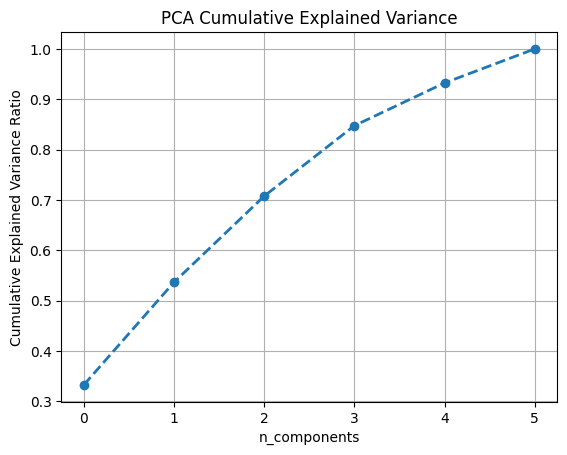

After PCA shape: (4694400, 5)


In [6]:
# Check explained variance first
pca_check = PCA(n_components=6).fit(X_scaled)
exp = pca_check.explained_variance_ratio_
print('Explained variance per component:', np.round(exp, 4))
print('Cumulative:', np.round(np.cumsum(exp), 4))

plt.plot(np.cumsum(exp), linewidth=2, marker='o', linestyle='--')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('n_components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# Use n=5 (~98% variance, same as kaggle notebook)
N_COMPONENTS = 5
ipca = IncrementalPCA(n_components=N_COMPONENTS)
X_pca = ipca.fit_transform(X_scaled)
print(f'After PCA shape: {X_pca.shape}')

In [7]:
X_train, X_eval, y_train, y_eval = train_test_split(
    X_pca, y, test_size=0.2, random_state=SEED, stratify=y
)
print('X_train:', X_train.shape, '| X_eval:', X_eval.shape)

# LightGBM
LGBM = LGBMClassifier(objective='multiclass', num_class=3,
                      random_state=SEED, n_jobs=-1, verbose=-1)
LGBM.fit(X_train, y_train)
LGBM_acc = accuracy_score(y_eval, LGBM.predict(X_eval))
print(f'LGBMClassifier Accuracy: {LGBM_acc:.4f}')

# XGBoost
XGB = XGBClassifier(objective='multi:softmax', num_class=3,
                    random_state=SEED, n_jobs=-1,
                    tree_method='hist', eval_metric='mlogloss',
                    early_stopping_rounds=30)
XGB.fit(X_train, y_train,
        eval_set=[(X_eval, y_eval)],
        verbose=False)
XGB_acc = accuracy_score(y_eval, XGB.predict(X_eval))
print(f'XGBClassifier  Accuracy: {XGB_acc:.4f}')

X_train: (3755520, 5) | X_eval: (938880, 5)
LGBMClassifier Accuracy: 0.8475
XGBClassifier  Accuracy: 0.8792


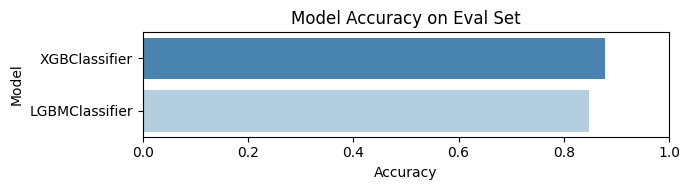

         Model  Accuracy
 XGBClassifier  0.879243
LGBMClassifier  0.847470

Using: XGB for submission


In [8]:
import seaborn as sns

results = pd.DataFrame({
    'Model':    ['LGBMClassifier', 'XGBClassifier'],
    'Accuracy': [LGBM_acc,          XGB_acc]
}).sort_values('Accuracy', ascending=False)

f, ax = plt.subplots(figsize=(7, 2))
sns.barplot(x='Accuracy', y='Model', data=results, ax=ax, palette='Blues_r')
ax.set_xlim(0, 1.0)
ax.set_title('Model Accuracy on Eval Set')
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

# Pick best model
best_model = XGB if XGB_acc >= LGBM_acc else LGBM
print(f'\nUsing: {"XGB" if XGB_acc >= LGBM_acc else "LGBM"} for submission')

In [9]:
HALF_WIN = 160   # samples either side of label timestamp (320 total @ 32Hz)

def extract_window(sensor_df, pid, ts_ms):
    grp = sensor_df[sensor_df['pid'] == pid].reset_index(drop=True)
    if grp.empty:
        return None
    idx = (grp['timestamp'] - ts_ms).abs().idxmin()
    start = max(0, idx - HALF_WIN)
    end   = start + 320
    if end > len(grp):
        end   = len(grp)
        start = max(0, end - 320)
    w = grp.iloc[start:end]
    return w if len(w) == 320 else None

test_rows = []
test_ids  = []

for _, row in TEST_LABEL.iterrows():
    pid = str(row['pid'])
    ts  = row['timestamp']
    rid = int(row['id'])

    w = extract_window(TEST_DATA, pid, ts)
    if w is None:
        test_rows.append({c: 0.0 for c in FEATURE_COLS})
    else:
        test_rows.append({
            'accel_x':     w['accel_x'].mean(),
            'accel_y':     w['accel_y'].mean(),
            'accel_z':     w['accel_z'].mean(),
            'eda':         w['eda'].mean(),
            'heart_rate':  w['heart_rate'].mean(),
            'temperature': w['temperature'].mean(),
        })
    test_ids.append(rid)

X_test_raw = pd.DataFrame(test_rows, columns=FEATURE_COLS)

# Apply same scaler + PCA
X_test_scaled = scaler.transform(X_test_raw)
X_test_pca    = ipca.transform(X_test_scaled)
print('Test feature shape:', X_test_pca.shape)

Test feature shape: (1028, 5)


In [10]:
y_pred_test = best_model.predict(X_test_pca)

submission = pd.DataFrame({'id': test_ids, 'stress': y_pred_test.astype(int)})
submission.to_csv('subn2.csv', index=False)

print(f'Saved subn1.csv — {len(submission)} rows')
print('Prediction distribution:')
print(submission['stress'].value_counts().sort_index())
print(submission.head())

Saved subn1.csv — 1028 rows
Prediction distribution:
stress
0    251
1     75
2    702
Name: count, dtype: int64
     id  stress
0  1227       2
1  1228       2
2  1229       2
3  1230       2
4  1231       2
